In [1]:
import pandas as pd
import numpy as np

In [2]:
data=pd.read_csv("../data/raw/supply_chain_data.csv")

In [3]:
data.head()

,shipment_id,supplier,product,distance_km,order_quantity,supplier_reliability,historical_delay_rate,lead_time_days,inventory_level,supplier_capacity,shipping_cost,weather_risk,demand_forecast,delay
0,SHP00001,Supplier_C,Batteries,805,972,0.77,0.33,14,1208,5552,3109.13,0.27,660,1
1,SHP00002,Supplier_D,Sensors,1120,601,0.93,0.05,5,287,4501,10443.46,0.56,2301,0
2,SHP00003,Supplier_A,Processors,2163,242,0.87,0.13,16,1545,3077,5077.64,0.39,1638,1
3,SHP00004,Supplier_C,Batteries,1546,1712,0.77,0.18,7,1099,9526,17613.17,0.17,2967,1
4,SHP00005,Supplier_C,Microchips,3764,338,0.84,0.24,2,236,5755,3879.20,0.07,2531,1


In [4]:
data.shape

(5000, 14)

In [5]:
data.columns

Index(['shipment_id', 'supplier', 'product', 'distance_km', 'order_quantity',
       'supplier_reliability', 'historical_delay_rate', 'lead_time_days',
       'inventory_level', 'supplier_capacity', 'shipping_cost', 'weather_risk',
       'demand_forecast', 'delay'],
      dtype='str')

In [6]:
data=data.drop(columns=["shipment_id"])

In [7]:
x=data.drop(columns=["delay"])

In [8]:
y=data["delay"]

In [9]:
x.shape

(5000, 12)

In [10]:
y.shape

(5000,)

In [11]:
categorical_cols=x.select_dtypes(
    include=["object"]
).columns.tolist()

C:\Users\Asus\AppData\Local\Temp\ipykernel_21396\4032394571.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=x.select_dtypes(


In [12]:
categorical_cols

['supplier', 'product']

In [13]:
numerical_cols = x.select_dtypes(
    exclude=["object"]
).columns.tolist()

numerical_cols

['distance_km',
 'order_quantity',
 'supplier_reliability',
 'historical_delay_rate',
 'lead_time_days',
 'inventory_level',
 'supplier_capacity',
 'shipping_cost',
 'weather_risk',
 'demand_forecast']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)

In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [18]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [19]:
x_train_processed.shape

(4000, 19)

In [20]:
x_test_processed.shape

(1000, 19)

In [21]:
import joblib

joblib.dump(
    preprocessor,
    "../ml/preprocessor.pkl"
)

['../ml/preprocessor.pkl']

In [22]:
from xgboost import XGBClassifier

In [23]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [24]:
model.fit(
    x_train_processed,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [32]:
joblib.dump(
    model,
    "../ml/xgboost_delay_model.pkl"
)

['../ml/xgboost_delay_model.pkl']

In [25]:
y_pred=model.predict(x_test_processed)

In [26]:
y_pred_proba=model.predict_proba(x_test_processed)[:,1]

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.603
Precision: 0.594
Recall   : 0.5682
F1 Score : 0.5808
ROC-AUC  : 0.6467


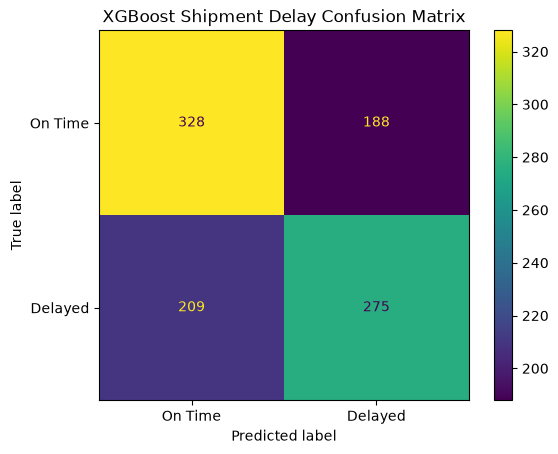

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On Time", "Delayed"]
)

disp.plot()
plt.title("XGBoost Shipment Delay Confusion Matrix")
plt.show()

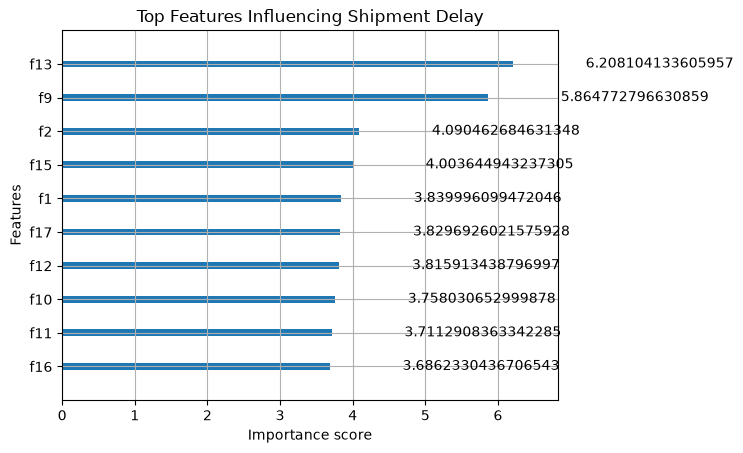

In [30]:
import xgboost as xgb

xgb.plot_importance(
    model,
    max_num_features=10,
    importance_type="gain"
)

plt.title("Top Features Influencing Shipment Delay")
plt.show()